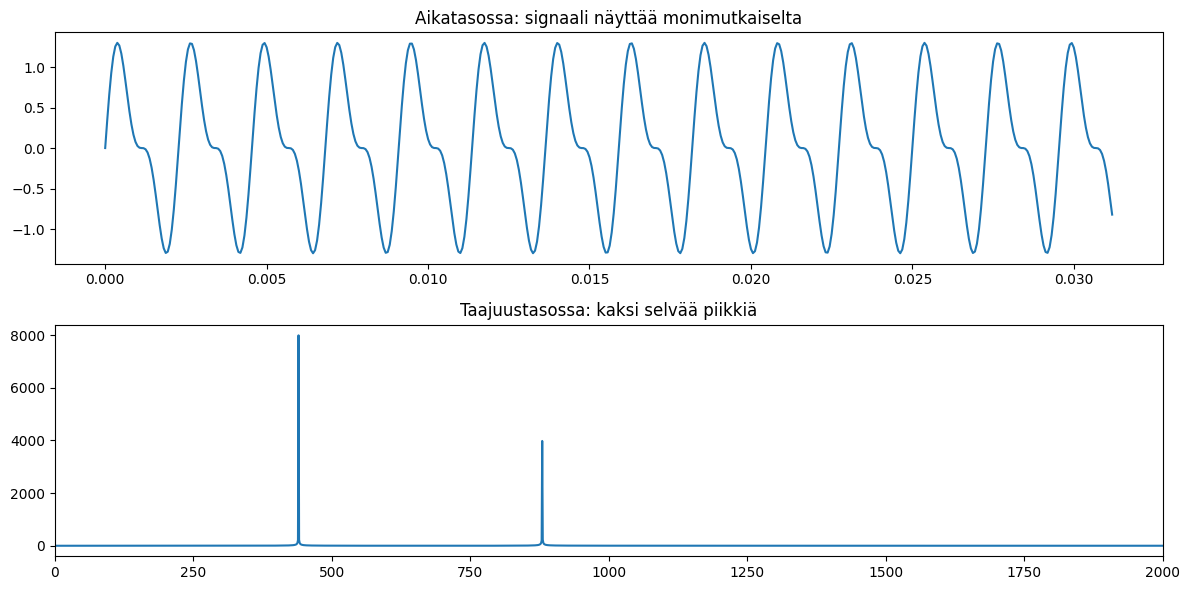

In [1]:
# ─────────────────────────────────────────────
# PART 0: Discrete Fourier Transform (DFT)
# ─────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import librosa
import librosa.display

sr = 16000
t = np.linspace(0, 1, sr)

# Rakennetaan signaali kahdesta taajuudesta
f1, f2 = 440, 880
signal = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

display(Audio(signal, rate=sr))

# DFT
spectrum = np.abs(np.fft.rfft(signal))
freqs = np.fft.rfftfreq(len(signal), 1/sr)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t[:500], signal[:500])
axes[0].set_title('Aikatasossa: signaali näyttää monimutkaiselta')
axes[1].plot(freqs, spectrum)
axes[1].set_xlim(0, 2000)
axes[1].set_title('Taajuustasossa: kaksi selvää piikkiä')
plt.tight_layout()

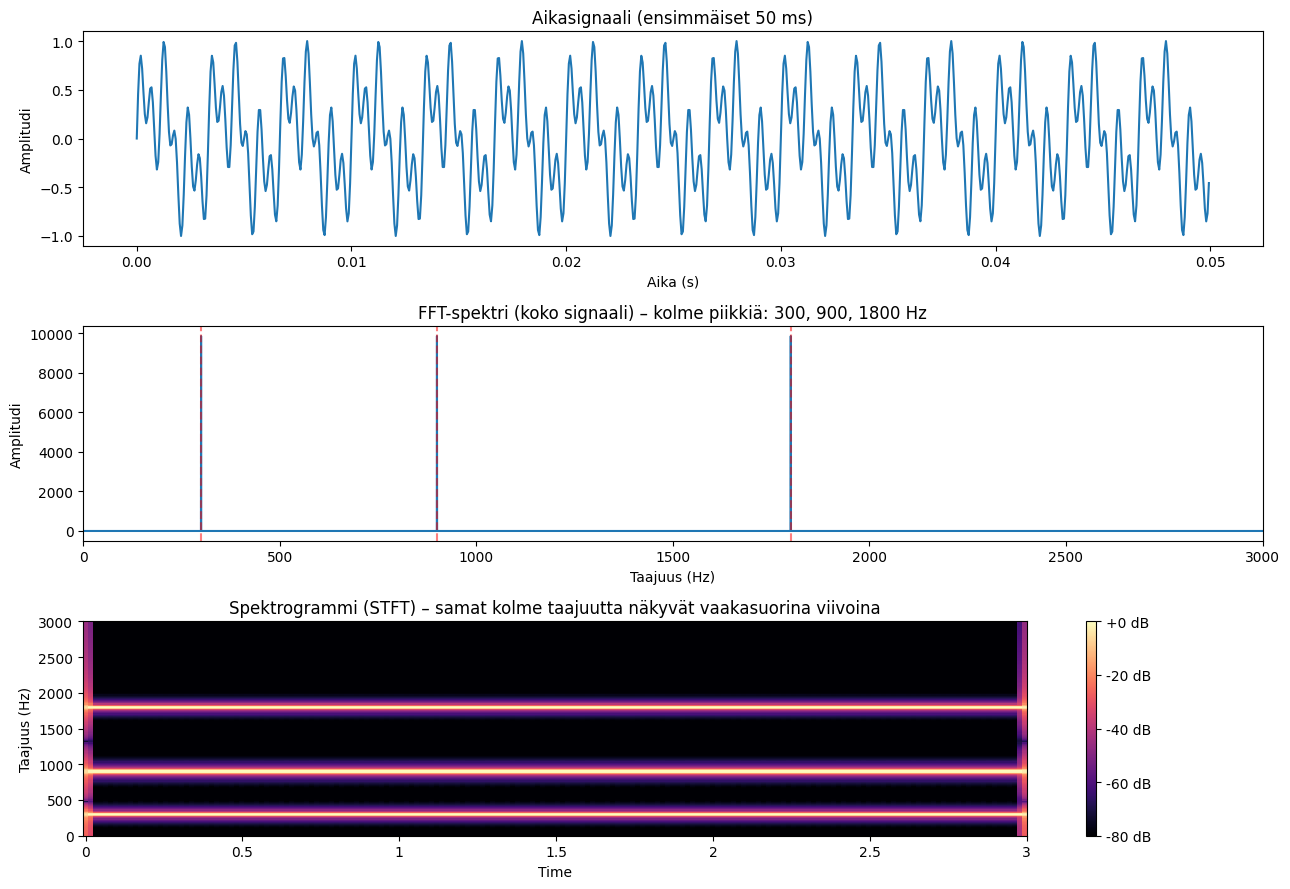

Huomio: FFT laski spektrin koko signaalille kerralla.
STFT laskee FFT:n lyhyissä ikkunoissa ja pinoa ne vierekkäin → spektrogrammi.


In [2]:
# ─────────────────────────────────────────────
# PART 1: From FFT spectrum to spectrogram
# ─────────────────────────────────────────────

# Signal: 3 sine waves, 3 seconds long
t = np.linspace(0, 3, 3 * sr, endpoint=False)
freqs_part1 = [300, 900, 1800]
signal1 = (np.sin(2 * np.pi * 300  * t) +
           np.sin(2 * np.pi * 900  * t) +
           np.sin(2 * np.pi * 1800 * t))
signal1 /= np.max(np.abs(signal1))  # normalize

display(Audio(signal1, rate=sr))

# --- 1a. FFT of the full signal ---
spectrum = np.abs(np.fft.rfft(signal1))
freq_axis = np.fft.rfftfreq(len(signal1), 1 / sr)

fig, axes = plt.subplots(3, 1, figsize=(13, 9))

axes[0].plot(t[:800], signal1[:800])
axes[0].set_title("Aikasignaali (ensimmäiset 50 ms)")
axes[0].set_xlabel("Aika (s)")
axes[0].set_ylabel("Amplitudi")

axes[1].plot(freq_axis, spectrum)
axes[1].set_xlim(0, 3000)
axes[1].set_title("FFT-spektri (koko signaali) – kolme piikkiä: 300, 900, 1800 Hz")
axes[1].set_xlabel("Taajuus (Hz)")
axes[1].set_ylabel("Amplitudi")
for f in freqs_part1:
    axes[1].axvline(f, color='red', linestyle='--', alpha=0.5)

# --- 1b. STFT → spectrogram (same signal, but now time axis appears) ---
n_fft = 1024
hop_length = 256
D = np.abs(librosa.stft(signal1, n_fft=n_fft, hop_length=hop_length))
D_db = librosa.amplitude_to_db(D, ref=np.max)

img = librosa.display.specshow(D_db, sr=sr, hop_length=hop_length,
                                x_axis='time', y_axis='linear', ax=axes[2])
axes[2].set_ylim(0, 3000)
axes[2].set_title("Spektrogrammi (STFT) – samat kolme taajuutta näkyvät vaakasuorina viivoina")
axes[2].set_ylabel("Taajuus (Hz)")
fig.colorbar(img, ax=axes[2], format='%+2.0f dB')

plt.tight_layout()
plt.show()

print("Huomio: FFT laski spektrin koko signaalille kerralla.")
print("STFT laskee FFT:n lyhyissä ikkunoissa ja pinoa ne vierekkäin → spektrogrammi.")



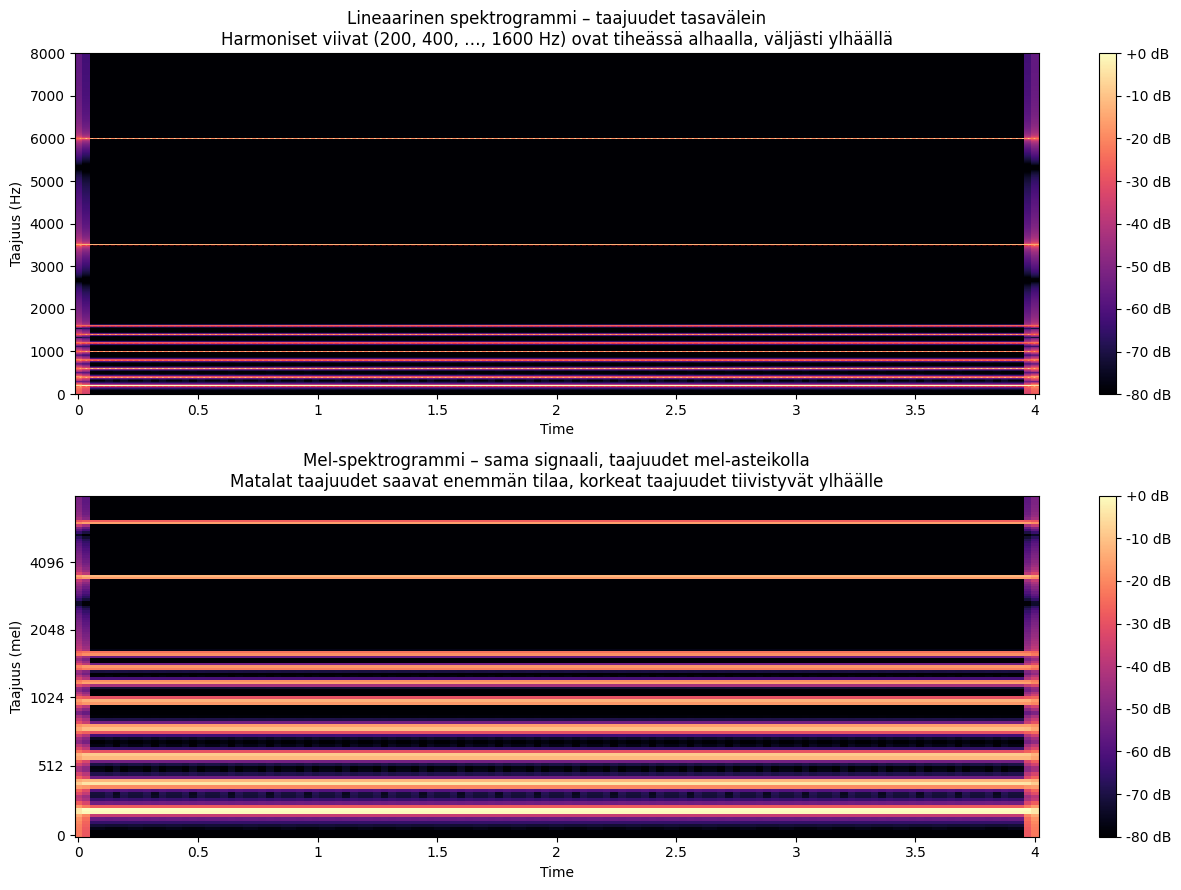


Huomio mel-asteikosta:
  Alimmat 8 harmonista (200–1600 Hz) kattavat mel-asteikosta noin
  42% koko skaalasta, vaikka Hz-asteikolla ne ovat vain 20% kaistasta.
  Ihmiskorva erottaa matalat taajuudet tarkemmin – mel-asteikko heijastaa tätä.


In [3]:
# ─────────────────────────────────────────────
# PART 2: Linear spectrogram vs. Mel spectrogram
# ─────────────────────────────────────────────

# Richer signal: 8 harmonics of a 200 Hz fundamental (like a buzzy instrument),
# plus two separate tones, 4 seconds
t2 = np.linspace(0, 4, 4 * sr, endpoint=False)

fundamental = 200
harmonics = [fundamental * k for k in range(1, 9)]   # 200–1600 Hz
extra      = [3500, 6000]                              # two high tones

signal2 = sum(np.sin(2 * np.pi * f * t2) / k for k, f in enumerate(harmonics, 1))
signal2 += 0.4 * np.sin(2 * np.pi * 3500 * t2)
signal2 += 0.3 * np.sin(2 * np.pi * 6000 * t2)
signal2 /= np.max(np.abs(signal2))

display(Audio(signal2, rate=sr))

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# --- 2a. Log-power spectrogram (linear frequency axis) ---
D2 = np.abs(librosa.stft(signal2, n_fft=2048, hop_length=512))
D2_db = librosa.amplitude_to_db(D2, ref=np.max)

img1 = librosa.display.specshow(D2_db, sr=sr, hop_length=512,
                                  x_axis='time', y_axis='linear', ax=axes[0])
axes[0].set_title("Lineaarinen spektrogrammi – taajuudet tasavälein\n"
                   "Harmoniset viivat (200, 400, …, 1600 Hz) ovat tiheässä alhaalla, väljästi ylhäällä")
axes[0].set_ylabel("Taajuus (Hz)")
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')
for f in harmonics + extra:
    axes[0].axhline(f, color='red', linestyle='--', alpha=0.3, linewidth=0.8)

# --- 2b. Mel spectrogram ---
n_mels = 128
M = librosa.feature.melspectrogram(y=signal2, sr=sr, n_fft=2048,
                                    hop_length=512, n_mels=n_mels)
M_db = librosa.power_to_db(M, ref=np.max)

img2 = librosa.display.specshow(M_db, sr=sr, hop_length=512,
                                  x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title("Mel-spektrogrammi – sama signaali, taajuudet mel-asteikolla\n"
                   "Matalat taajuudet saavat enemmän tilaa, korkeat taajuudet tiivistyvät ylhäälle")
axes[1].set_ylabel("Taajuus (mel)")
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

print("\nHuomio mel-asteikosta:")
print(f"  Alimmat 8 harmonista (200–1600 Hz) kattavat mel-asteikosta noin")
mel_low  = librosa.hz_to_mel(200)
mel_high = librosa.hz_to_mel(1600)
mel_top  = librosa.hz_to_mel(sr / 2)
frac = (mel_high - mel_low) / mel_top
print(f"  {frac*100:.0f}% koko skaalasta, vaikka Hz-asteikolla ne ovat vain "
      f"{1600/(sr/2)*100:.0f}% kaistasta.")
print("  Ihmiskorva erottaa matalat taajuudet tarkemmin – mel-asteikko heijastaa tätä.")